In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!git clone https://github.com/nipponjo/tts-arabic-pytorch.git



Cloning into 'tts-arabic-pytorch'...
remote: Enumerating objects: 337, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 337 (delta 56), reused 48 (delta 48), pack-reused 266 (from 2)
Receiving objects: 100% (337/337), 3.32 MiB | 12.15 MiB/s, done.
Resolving deltas: 100% (160/160), done.


In [3]:
!mv tts-arabic-pytorch/* tts-arabic-pytorch/.* /content 2>/dev/null

In [4]:
!pip install fastapi uvicorn pyngrok nest_asyncio torch matplotlib scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 kB 4.8 MB/s eta 0:00:00


In [5]:
pip install python-multipart

In [6]:
!ngrok config add-authtoken 2qXblkQKeLGXLUGuI4rHL6rKQb3_6fuCGYm63GZh5dkFCaRpJ


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


ERROR:asyncio:Task exception was never retrieved
future: <Task finished name='Task-1' coro=<Server.serve() done, defined at /usr/local/lib/python3.10/dist-packages/uvicorn/server.py:68> exception=KeyboardInterrupt()>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/uvicorn/main.py", line 579, in run
    server.run()
  File "/usr/local/lib/python3.10/dist-packages/uvicorn/server.py", line 66, in run
    return asyncio.run(self.serve(sockets=sockets))
  File "/usr/local/lib/python3.10/dist-packages/nest_asyncio.py", line 30, in run
    return loop.run_until_complete(task)
  File "/usr/local/lib/python3.10/dist-packages/nest_asyncio.py", line 92, in run_until_complete
    self._run_once()
  File "/usr/local/lib/python3.10/dist-packages/nest_asyncio.py", line 133, in _run_once
    handle._run()
  File "/usr/lib/python3.10/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "/usr/lib/python3.10/asyncio/tasks.py", l

Public URL: https://593a-35-247-123-243.ngrok-free.app


INFO:     Started server process [1631]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     154.180.33.162:0 - "GET / HTTP/1.1" 200 OK
INFO:     154.180.33.162:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
Text received: السلام عليكم


/usr/local/lib/python3.10/dist-packages/torchaudio/models/tacotron2.py:856: UserWarning: Reached max decoder steps. The generated spectrogram might not cover the whole transcript.
  warnings.warn(


INFO:     154.180.33.162:0 - "POST /generate HTTP/1.1" 200 OK
INFO:     154.180.33.162:0 - "GET /download_spectrogram HTTP/1.1" 200 OK
INFO:     154.180.33.162:0 - "GET /download_audio HTTP/1.1" 206 Partial Content
INFO:     154.180.33.162:0 - "GET /download_audio HTTP/1.1" 206 Partial Content
INFO:     154.180.33.162:0 - "GET /download_audio HTTP/1.1" 206 Partial Content


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [1631]


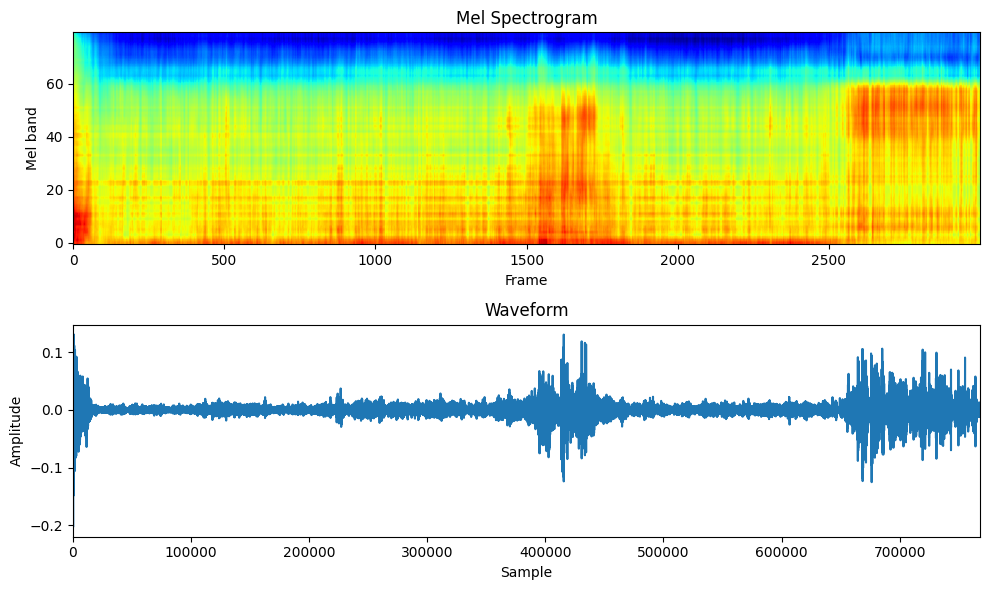

In [2]:
from fastapi import FastAPI, Form, Request
from fastapi.responses import HTMLResponse, FileResponse
from fastapi.middleware.cors import CORSMiddleware
from pyngrok import ngrok
import nest_asyncio
import uvicorn
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
from models.tacotron2 import Tacotron2Wave

# Apply the nest_asyncio patch for Jupyter environments (for running FastAPI in Colab)
nest_asyncio.apply()

# Initialize FastAPI app
app = FastAPI()

# Allow CORS (optional)
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# Load the Tacotron2 model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Tacotron2Wave('/content/drive/MyDrive/tts-arabic-pytorch/checkpoints/exp_tc2_adv/epoch_4_states.pth')
model = model.to(device=device)

# Set paths for saving the audio and spectrogram
audio_path = '/content/audio_output.wav'
spectrogram_path = '/content/spectrogram_waveform.png'

@app.get("/", response_class=HTMLResponse)
async def home():
    return """
    <html>
        <head>
            <style>
                body {
                    display: flex;
                    justify-content: center;
                    align-items: center;
                    height: 100vh;
                    margin: 0;
                    font-family: Arial, sans-serif;
                    background-color: #f0f0f0;
                }
                .container {
                    text-align: center;
                    padding: 20px;
                    background-color: white;
                    border-radius: 8px;
                    box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1);
                    width: 80%;
                    max-width: 600px;
                }
                h2 {
                    font-size: 24px;
                    margin-bottom: 20px;
                }
                form {
                    margin-top: 20px;
                }
                input[type="text"] {
                    width: 80%;
                    padding: 10px;
                    margin-bottom: 20px;
                }
                input[type="submit"] {
                    background-color: #4CAF50;
                    color: white;
                    border: none;
                    padding: 10px 20px;
                    border-radius: 5px;
                    cursor: pointer;
                }
                input[type="submit"]:hover {
                    background-color: #45a049;
                }
            </style>
        </head>
        <body>
            <div class="container">
                <h2>Arabic Text-to-Speech (Tacotron2)</h2>
                <form action="/generate" method="post" enctype="application/x-www-form-urlencoded">
                    <input type="text" name="text" placeholder="Enter Arabic text here" required>
                    <br>
                    <input type="submit" value="Generate Audio and Spectrogram">
                </form>
            </div>
        </body>
    </html>
    """

@app.post("/generate", response_class=HTMLResponse)
async def generate(request: Request, text: str = Form(...)):
    try:
        print(f"Text received: {text}")  # Debugging log
        if not text.strip():
            return "Error: No text provided. Please enter some text."

        # Generate wave and mel spectrogram using Tacotron2
        wave, mel_spec = model.tts(text, return_mel=True, denoise=0.005)

        # Normalize the waveform to save as audio
        wave = wave.cpu().numpy()
        normalized_wave = np.int16(wave / np.max(np.abs(wave)) * 32767)

        # Save audio as a .wav file
        wav.write(audio_path, 22050, normalized_wave)

        # Plot and save the spectrogram and waveform
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
        ax1.imshow(mel_spec.cpu(), origin='lower', aspect='auto', cmap='jet')
        ax1.set_xlabel('Frame')
        ax1.set_ylabel('Mel band')
        ax1.set_title("Mel Spectrogram")
        ax2.plot(wave)
        ax2.set_xlim(0, len(wave))
        ax2.set_xlabel('Sample')
        ax2.set_ylabel('Amplitude')
        ax2.set_title("Waveform")
        fig.tight_layout()
        plt.savefig(spectrogram_path)

        # Return HTML with audio and combined spectrogram and waveform
        return f"""
        <html>
            <body style="text-align: center; font-family: Arial, sans-serif;">
                <h2>Generated Audio, Spectrogram, and Waveform</h2>
                <audio controls>
                    <source src="/download_audio" type="audio/wav">
                    Your browser does not support the audio element.
                </audio>
                <br><br>
                <img src="/download_spectrogram" alt="Mel Spectrogram and Waveform">
                <br><br>
                <a href="/">Go Back</a>
            </body>
        </html>
        """
    except Exception as e:
        print(f"Error: {e}")
        return f"Error: {str(e)}"

@app.get("/download_audio")
async def download_audio():
    return FileResponse(audio_path, media_type="audio/wav", filename="output.wav")

@app.get("/download_spectrogram")
async def download_spectrogram():
    return FileResponse(spectrogram_path, media_type="image/png", filename="spectrogram_waveform.png")

# Start FastAPI server with ngrok
ngrok_tunnel = ngrok.connect(8000)
print(f"Public URL: {ngrok_tunnel.public_url}")

# Run the server
uvicorn.run(app, host="0.0.0.0", port=8000)
